# PV-BESS optimizer - full year

Example Jupyter notebook for scheduling a PV-BESS system using the Pyomo optimization framework.
This jupyter notebook sets up the model, defines the variables, constraints, and objective function,
and then solves the optimization problem to determine the optimal charging and discharging schedule.

### Imports

In [1]:
# Import necessary libraries
from scheduler import get_schedule # Import the scheduler module which contains the Pyomo model and optimization logic
import matplotlib.pyplot as plt  # Import matplotlib for plotting results
import pandas as pd  # Import pandas for data handling

### Set the input parameters

In [2]:
# BESS (Battery Energy Storage System) parameters
p_limit = 10  # Maximum injection power limit
storage_capacity = 5 # Storage capacity in MWh
p_charge_max = 2.5 # Maximum charge power in MW
p_discharge_max = 2.5 # Maximum discharge power MW
efficiency = 0.95 # Charge/discharge efficiency of the BESS
start_soc = 0.0  # Initial state of charge
end_soc = 0.0  # End state of charge, can be adjusted as needed
number_of_cycles = 2 * 7  # Number of cycles for the period (week)

# General parameters
number_of_weeks = 52  # Number of weeks in the year
year = '2024'  # Year for which the data is being processed

# Commercial parameters
applicable_value = 58.9 # Applicable value for the plant from EEG or tender in €/MWh

# Initialize lists to store results
pv_output = []
daa = [] # Lists to store PV output and DAA prices

### Year data dictionary

In [3]:
year_data = {
            # '2020': [24.6,'./data/2020/DA/2020_daa.csv',
            #                   './data/2020/IDA/2020_ida.csv' ,
            #                   './data/2020/ID1/2020_id1.csv',
            #                   './data/2020/PV/2020_pv.csv',
            #                   '2020-01-06 00:00:00'], 
            #  '2021': [75.5,'./data/2021/DA/2021_daa.csv',
            #                   './data/2021/IDA/2021_ida.csv' ,
            #                   './data/2021/ID1/2021_id1.csv',
            #                   './data/2021/PV/2021_pv.csv',
            #                   '2021-01-04 00:00:00'], 
            #  '2022': [223.1,'./data/2022/DA/2022_daa.csv',
            #                   './data/2022/IDA/2022_ida.csv' ,
            #                   './data/2022/ID1/2022_id1.csv',
            #                   './data/2022/PV/2022_pv.csv',
            #                   '2022-01-03 00:00:00'], 
            #  '2023': [72.0,'./data/2023/DA/2023_daa.csv',
            #                   './data/2023/IDA/2023_ida.csv' ,
            #                   './data/2023/ID1/2023_id1.csv',
            #                   './data/2023/PV/2023_pv.csv',
            #                   '2023-01-02 00:00:00'],
             '2024': [46.24,'./data/2024/DA/2024_daa.csv',
                              './data/2024/IDA/2024_ida.csv' ,
                              './data/2024/ID1/2024_id1.csv',
                              './data/2024/PV/2024_pv.csv',
                              '2024-01-01 00:00:00'], 
            }
# Extract the market value for the specified year
market_value = year_data[year][0]

### Load DAA data from files

In [4]:
daa = pd.read_csv(year_data[year][1], index_col = 0)
daa.index = pd.to_datetime(daa.index)


### Load PV load profile from .csv:

In [5]:
pv = pd.read_csv(year_data[year][4], index_col = 0)
pv.index = pd.to_datetime(pv.index)
pv.PV = [max(0, v) for v in pv.PV] # Set negative values to zero


### Get the optimzized schedule
This is done for weekly time slices. The results for the single weeks are then concatenated into a result dataframe.   

In [6]:
start = pd.to_datetime(year_data[year][5])
end = start + pd.DateOffset(days=7) - pd.DateOffset(minutes=15)  # Set end to the next week minus 15 minutes
result_list = []

for i in range(1, number_of_weeks + 1):
    print('start/end', start, end)
    pv_vector = pv.PV[start:end].to_list()
    daa_price_vector = daa.DAA[start:end].to_list()
    
    # Ensure the vectors are not empty
    if not pv_vector or not daa_price_vector:
        raise ValueError("PV output and DAA price vectors cannot be empty.")

    # Ensure the vectors are of the same length
    if len(pv_vector) != len(daa_price_vector): 
        raise ValueError("PV output and DAA price vectors must have the same length.")

    pv_output, daa_price, p_charge, p_discharge, soc, p_curtailed, injection_power = get_schedule(pv_vector,
                                                                                                  daa_price_vector, 
                                                                                                  p_limit, 
                                                                                                  storage_capacity, 
                                                                                                  p_charge_max, 
                                                                                                  p_discharge_max, 
                                                                                                  number_of_cycles, 
                                                                                                  efficiency, 
                                                                                                  start_soc, 
                                                                                                  end_soc)

    result = pd.DataFrame({'daa_price': daa_price,
                           'pv_output': pv_output,
                           'p_charge': p_charge,
                           'p_discharge': p_discharge,
                           'soc': soc,
                           'p_curtailed': p_curtailed,
                           'injection_power': injection_power
                          }
                         )
    
    result.index = pd.date_range(start=start, end=end, freq='15min')
    
    result_list.append(result)

    start = start + pd.DateOffset(days=7) # Set start and end to the next week
    end = end + pd.DateOffset(days=7)
    
results = pd.concat(result_list)

    

start/end 2024-01-01 00:00:00 2024-01-07 23:45:00
Running HiGHS 1.11.0 (git hash: 364c83a): Copyright (c) 2025 HiGHS under MIT licence terms
MIP  has 7397 rows; 3361 cols; 14116 nonzeros; 672 integer variables (672 binary)
Coefficient ranges:
  Matrix [2e-01, 2e+00]
  Cost   [3e-03, 4e+01]
  Bound  [1e+00, 1e+00]
  RHS    [1e-02, 7e+01]
Presolving model
3361 rows, 2904 cols, 9168 nonzeros  0s
2234 rows, 2232 cols, 6933 nonzeros  0s
1736 rows, 1337 cols, 4217 nonzeros  0s
1298 rows, 1335 cols, 3339 nonzeros  0s

Solving MIP model with:
   1298 rows
   1335 cols (240 binary, 0 integer, 0 implied int., 1095 continuous, 0 domain fixed)
   3339 nonzeros

Src: B => Branching; C => Central rounding; F => Feasibility pump; J => Feasibility jump;
     H => Heuristic; L => Sub-MIP; P => Empty MIP; R => Randomized rounding; Z => ZI Round;
     I => Shifting; S => Solve LP; T => Evaluate node; U => Unbounded; X => User solution;
     z => Trivial zero; l => Trivial lower; u => Trivial upper; p => 

In [7]:
pd.set_option("display.max_columns", None)
results.head()
# results.loc['2023-10-31 17:00:00']

,daa_price,pv_output,p_charge,p_discharge,soc,p_curtailed,injection_power
2024-01-01 00:00:00,0.10,0.0,0.0,0.0,0.0,0.0,0.0
2024-01-01 00:15:00,0.10,0.0,0.0,0.0,0.0,0.0,0.0
2024-01-01 00:30:00,0.10,0.0,0.0,0.0,0.0,0.0,0.0
2024-01-01 00:45:00,0.10,0.0,0.0,0.0,0.0,0.0,0.0
2024-01-01 01:00:00,0.01,0.0,0.0,0.0,0.0,0.0,0.0


### Plot the results

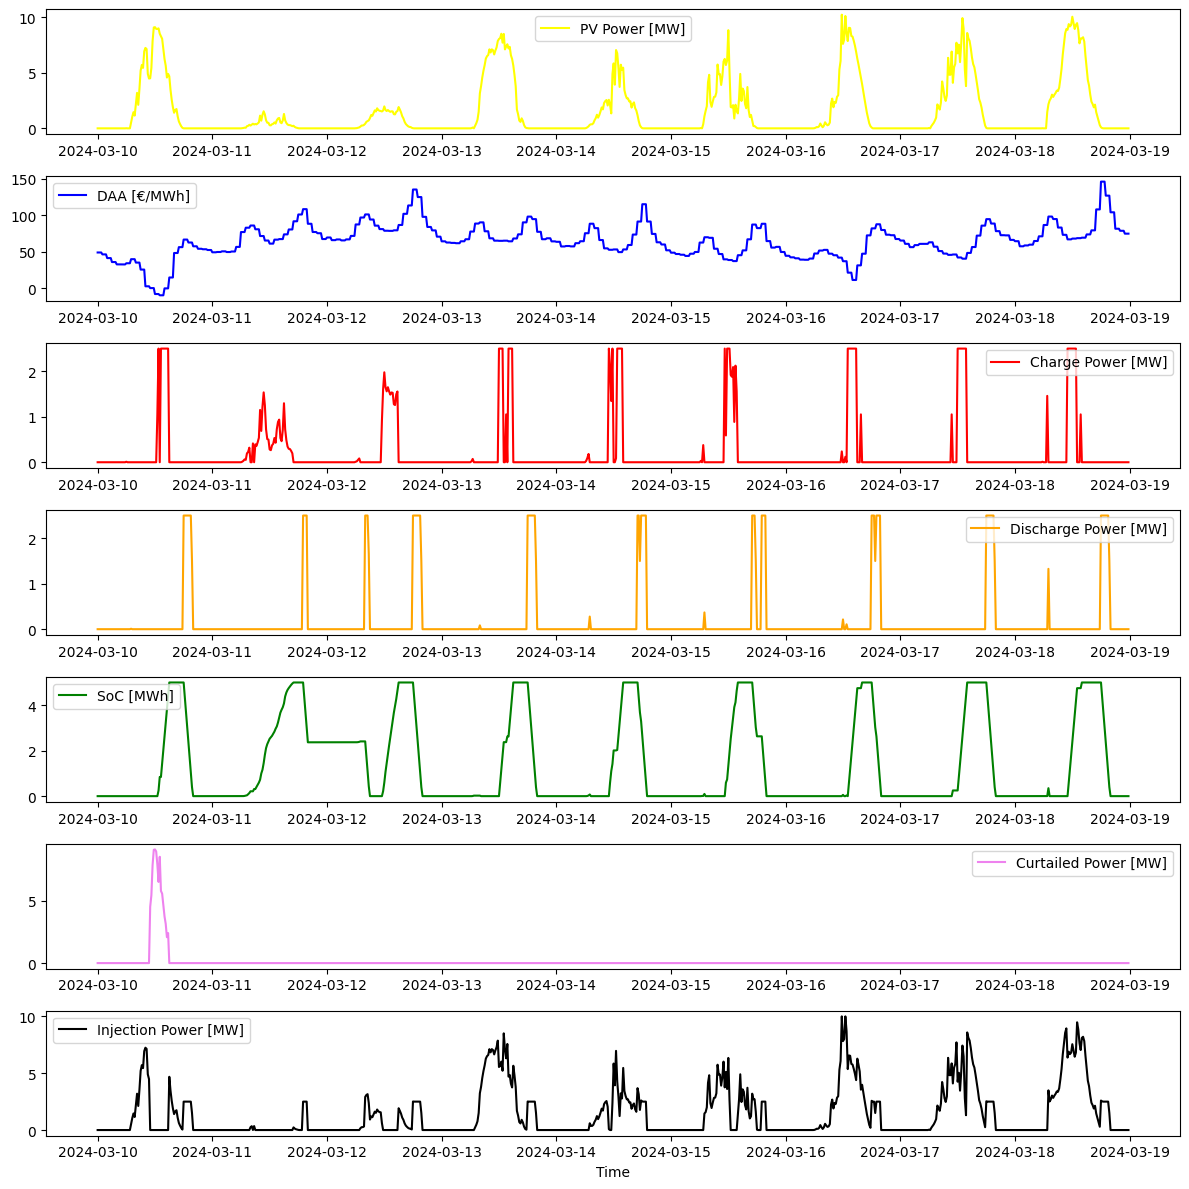

In [8]:
# Plotting the results
# Set timerange for plotting
plot_start = pd.to_datetime('2024-03-10 00:00:00')
plot_end = pd.to_datetime('2024-03-18 23:45:00')

results_slice = results[plot_start:plot_end]

fig, ax = plt.subplots(7, 1, figsize=(12,12))
ax[0].plot(results_slice.pv_output, label='PV Power [MW]', color='yellow')
ax[1].plot(results_slice.daa_price, label='DAA [€/MWh]', color='blue')
ax[2].plot(results_slice.p_charge, label='Charge Power [MW]', color='red')
ax[3].plot(results_slice.p_discharge, label='Discharge Power [MW]', color='orange')
ax[4].plot(results_slice.soc, label='SoC [MWh]', color='green')
ax[5].plot(results_slice.p_curtailed, label='Curtailed Power [MW]', color='violet')
ax[6].plot(results_slice.injection_power, label='Injection Power [MW]', color='black')


ax[6].set_xlabel('Time')

ax[0].legend()
ax[1].legend()
ax[2].legend()
ax[3].legend()
ax[4].legend()
ax[5].legend()
ax[6].legend()

plt.tight_layout()
# plt.show()
plt.savefig('results.png')

### Calculate energies and incomings

In [9]:
# Calculate energies
pv_energy = results.pv_output.sum() * 15 / 60  # Convert from MW to MWh
injected_energy = results.injection_power.sum() * 15 / 60  # Convert from MW to MWh
curtailed_energy = results.p_curtailed.sum() * 15 / 60 # Convert from MW to MWh
discharge_energy = results.p_discharge.sum() * 15 / 60  # Convert from MW to MWh
charge_energy = results.p_charge.sum() * 15 / 60  # Convert from MW to MWh

# Print calculated energies
print('Annual Energies:')
print('------------------------------------------')
print('PV Energy:', f'{pv_energy:.2f} MWh')
print('Injected Energy:', f'{injected_energy:.2f} MWh')
print('Curtailed Energy:', f'{curtailed_energy:.2f} MWh')
print('Charge Energy:', f'{charge_energy:.2f} MWh')
print('Discharge Energy:', f'{discharge_energy:.2f} MWh')
print('------------------------------------------')

# Calculate incomings
results['pv_direct_market_incoming'] = results.daa_price * results.pv_output * 15 / 60
results['injected_power_direct_market_incoming'] = results.daa_price * results.injection_power * 15 / 60

# Only sum up incoming, pv and injected power for positive market prices, because plant will be curtailed at other times
condition_daa_positive = results.daa_price >= 0
annual_pv_energy = results.loc[condition_daa_positive, 'pv_output'].sum() * 15 / 60
annual_pv_direct_market_incoming = results.loc[condition_daa_positive, 'pv_direct_market_incoming'].sum()

annual_injected_energy = results.loc[condition_daa_positive, 'injection_power'].sum() * 15 / 60
annual_injected_energy_direct_market_incoming = results.loc[condition_daa_positive, 'injected_power_direct_market_incoming'].sum()

# Print annual incoming values
print('Annual Direct Market Incomings:')
print('----------------------------------------------------------------------------------------')
print('Annual PV Energy:', f'{annual_pv_energy:.2f} MWh', '(excl. negative price hours)')
print('Annual PV Direct Market Incoming:', f'{annual_pv_direct_market_incoming:.2f} €', '(excl. negative price hours)')
print('Annual Injected Energy:', f'{annual_injected_energy:.2f} MWh', '(excl. negative price hours)')
print('Annual Injected Energy Direct Market Incoming:', f'{annual_injected_energy_direct_market_incoming:.2f} €', '(excl. negative price hours)')
print('----------------------------------------------------------------------------------------')

# Calculate annual market bonus
market_bonus_injected_energy = annual_injected_energy * (applicable_value - market_value)
market_bonus_pv_energy = annual_pv_energy * (applicable_value - market_value)

print('Annual Market Boni:')
print('------------------------------------------------------------------')
print('Annual Market Bonus PV + BESS:', f'{market_bonus_injected_energy:.2f} €')
print('Annual Market Bonus PV only:', f'{market_bonus_pv_energy:.2f} €')
print('------------------------------------------------------------------')

print('Final Results:')
print('------------------------------------------------------------')
print('Annual Income PV + BESS:', f'{market_bonus_injected_energy + annual_injected_energy_direct_market_incoming :.2f} MWh')
print('Annual Income PV only:', f'{market_bonus_pv_energy + annual_pv_direct_market_incoming:.2f} MWh')
print('Annual BESS profit:', f'{annual_injected_energy_direct_market_incoming + market_bonus_injected_energy 
                                - annual_pv_direct_market_incoming - market_bonus_pv_energy:.2f} €')
print('Specific Annual BESS profit:', f'{(annual_injected_energy_direct_market_incoming + market_bonus_injected_energy 
                                - annual_pv_direct_market_incoming - market_bonus_pv_energy) / storage_capacity:.2f} €/MWh')



Annual Energies:
------------------------------------------
PV Energy: 15899.99 MWh
Injected Energy: 12980.67 MWh
Curtailed Energy: 2741.79 MWh
Charge Energy: 1820.79 MWh
Discharge Energy: 1643.26 MWh
------------------------------------------
Annual Direct Market Incomings:
----------------------------------------------------------------------------------------
Annual PV Energy: 12886.42 MWh (excl. negative price hours)
Annual PV Direct Market Incoming: 784365.24 € (excl. negative price hours)
Annual Injected Energy: 12980.67 MWh (excl. negative price hours)
Annual Injected Energy Direct Market Incoming: 921609.28 € (excl. negative price hours)
----------------------------------------------------------------------------------------
Annual Market Boni:
------------------------------------------------------------------
Annual Market Bonus PV + BESS: 164335.25 €
Annual Market Bonus PV only: 163142.10 €
------------------------------------------------------------------
Final Results:
----